# Running 4D STEM simulations on 21.79$\degree$ twisted bilayer hBN
This notebook performs 4D STEM simulations using abTEM functionalities. Specifically, the following tasks are achieved in this notebook:

1. CBED patterns are collected at each scan position using parallel computing.
2. Virtual HAADF imaging is achieved using the calculated CBED patterns.
3. Center-of-mass calculations are performed using the simulated CBED patterns.
4. Electric field and charge density maps are derived using differential phase contrast.

## Part 1: Setting up the simulation

In [277]:
# Import all necessary packages
import numpy as np
import matplotlib.pyplot as plt
import ase
import abtem
from abtem import show_atoms
%run twisted_bilayers.py

In [278]:
# Set abTEM configuration parameters
abtem.config.set(
    {
        'device': 'cpu',
        'fft': 'fftw'
    }
)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

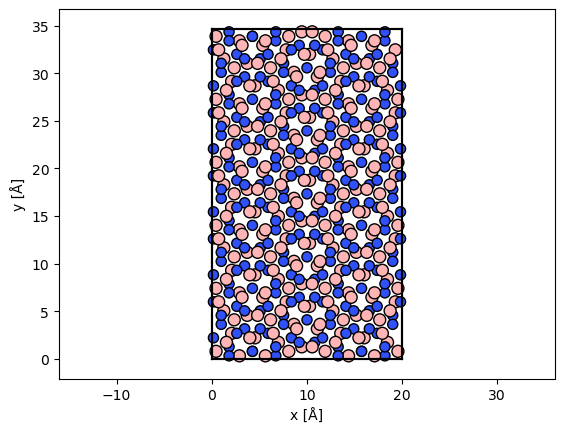

In [3]:
# Generate twisted bilayer structure
hBN = generate_twisted_bilayers('example CIFs/BN.cif', twist_angle=21.79)
show_atoms(hBN)

In [4]:
# Set simulation parameters
frozen_phonons = abtem.FrozenPhonons(hBN, 8, sigmas=0.1, ensemble_mean=True)
potential = abtem.Potential(frozen_phonons, sampling=0.05)
probe = abtem.Probe(energy=60e3, semiangle_cutoff=14)
probe.grid.match(potential)

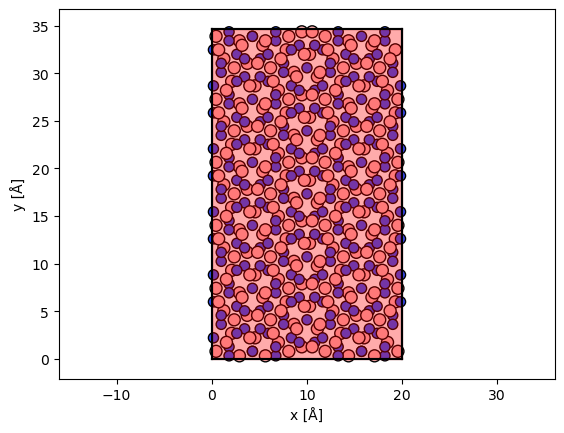

In [5]:
# Define the scan grid that the electron probe will raster across
grid_scan = abtem.GridScan(
    start=(0, 0),
    end=(1, 1),
    sampling=probe.aperture.nyquist_sampling,
    fractional=True,
    potential=potential
)

fig, ax = show_atoms(hBN)
grid_scan.add_to_plot(ax)

In [6]:
# Define a pixelated detector and scan across the sample to simulate 4D STEM
detector = abtem.PixelatedDetector(max_angle=200)
measurements = probe.scan(potential, scan=grid_scan, detectors=detector, lazy=True)
measurements = measurements.gaussian_source_size(0.3) # filtering

## Part 2: Performing the multislice calculations

### A note on parallel computing
Running multislice measurements at each scan position is going to be very memory-intensive. The following code blocks parallelize the calculations by treating the measurements as chunks from a Dask array. Zarr will then be used to parallelly compute and lazily load the diffraction data.

In [ ]:
# Load a Dask client
from dask.distributed import Client, LocalCluster

cluster = LocalCluster(
    n_workers=4,
    threads_per_worker=1,
    memory_limit='auto'
)
client = Client(cluster)

In [8]:
# Ensure measurements are loaded lazily
measurements = measurements.ensure_lazy()
try:
    measurements = measurements.no_base_chunks()
except AttributeError:
    pass

In [9]:
# Parallelize calculations through Zarr
zarr_path = 'diffraction_patterns.zarr'
measurements.to_zarr(zarr_path)
print('Finished computing all scan positions to Zarr:', zarr_path)

Finished computing all scan positions to Zarr: diffraction_patterns.zarr


In [10]:
# Load the data from Zarr lazily
lazy_measurements = abtem.measurements.DiffractionPatterns.from_zarr(zarr_path)

## Part 3: Visualizing the simulated 4D STEM dataset

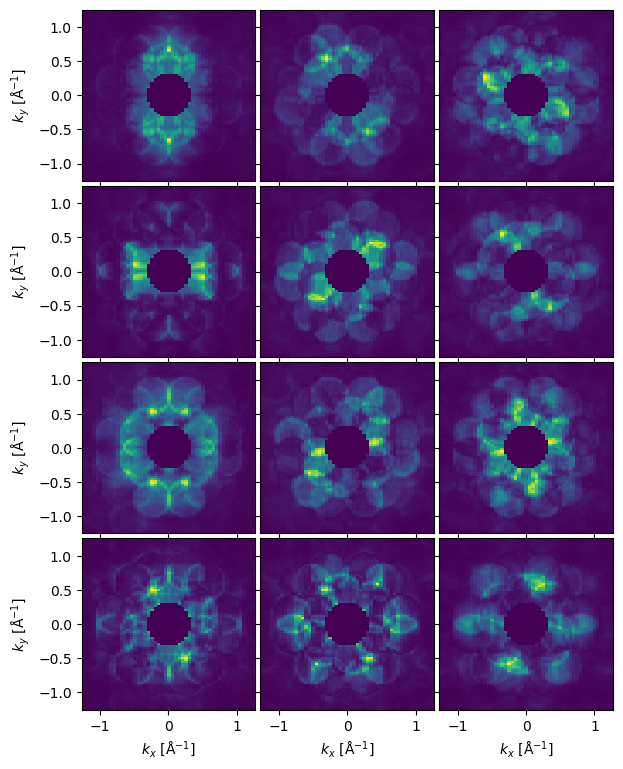

In [279]:
# Plotting a few select CBED patterns from the overall 4D STEM dataset
visualization = (
    lazy_measurements[::10,::10]
    .crop(60)
    .block_direct(radius=13)
    .show(explode=True, figsize=(8,8), title=None)
)
visualization.axes.set_sizes(padding=0.05)
visualization.get_figure().savefig('selectCBEDpatterns.svg', dpi=300, bbox_inches='tight')

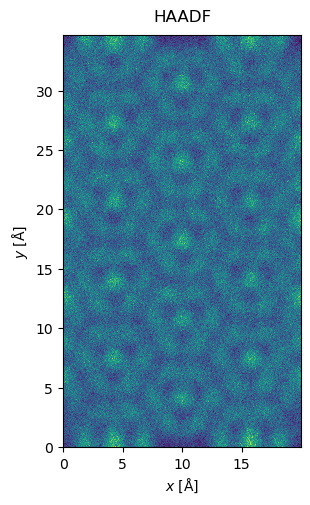

In [280]:
# Performing virtual HAADF imaging using all of the CBED patterns
haadf = (
    lazy_measurements.integrate_radial(50, 150)
    .interpolate(0.05)
    .poisson_noise(dose_per_area=1e7)
)

haadf_fig = haadf.show(title='HAADF')
haadf_fig.get_figure().savefig('HAADF.svg', dpi=300, bbox_inches='tight')

## Part 4: Performing center-of-mass calculations

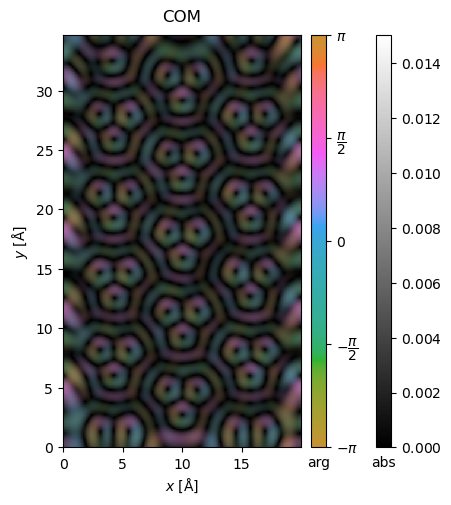

In [281]:
# Visualizing the complex center of mass map
center_of_mass = lazy_measurements.center_of_mass()
interpolated_center_of_mass = center_of_mass.interpolate(0.05)
COM_fig = interpolated_center_of_mass.show(cbar=True, vmax=0.015, vmin=0, title='COM')
COM_fig.get_figure().savefig('COM.svg', dpi=300, bbox_inches='tight')

In [282]:
# Create an artificial datacube compatible with numpy-based COM calculations
# Alternatively, this could be modified to integrate py4DSTEM functionalities
CBED = lazy_measurements.crop(60).block_direct(radius=13).array.compute()

In [283]:
# Function to calculate the COMs along the x and y directions from a 4D STEM datacube
# Source: https://github.com/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_07/lectures/lecture_7.2_com_dpc_analysis.ipynb
def calculate_com(datacube, beam_center=None, mask=None, show_progress=True):
    Rx, Ry, Qy, Qx = datacube.shape
    
    # Initialize COM arrays
    com_x = np.zeros((Rx, Ry))
    com_y = np.zeros((Rx, Ry))
    
    # Create coordinate arrays
    qy_coords, qx_coords = np.meshgrid(np.arange(Qy), np.arange(Qx), indexing='ij')
    
    # Apply mask if provided
    if mask is not None:
        qx_coords = qx_coords * mask
        qy_coords = qy_coords * mask
    
    # Calculate COM for each position
    if show_progress:
        print(f"Computing COM for {Rx}×{Ry} = {Rx*Ry} positions...")
    
    for i in range(Rx):
        if show_progress and (i % max(1, Rx//10) == 0):
            print(f"  Progress: {100*i//Rx}% ({i}/{Rx})")
        
        for j in range(Ry):
            dp = datacube[i, j, :, :]
            
            # Apply mask
            if mask is not None:
                dp = dp * mask
            
            total = np.sum(dp)
            
            if total > 0:
                com_x[i, j] = np.sum(dp * qx_coords) / total
                com_y[i, j] = np.sum(dp * qy_coords) / total
            else:
                # Handle zero intensity (use beam center)
                if beam_center is not None:
                    com_x[i, j], com_y[i, j] = beam_center
                else:
                    com_x[i, j] = Qx / 2
                    com_y[i, j] = Qy / 2
    
    if show_progress:
        print("  Progress: 100% - Complete!")
    
    # Shift to be relative to beam center
    if beam_center is not None:
        cx, cy = beam_center
        com_x -= cx
        com_y -= cy
    
    return com_x, com_y

# Calculate COM
Qy = CBED.shape[2]
Qx = CBED.shape[3]

com_x, com_y = calculate_com(
    CBED,
    beam_center=(Qx/2, Qy/2),
    show_progress=False
)

print(f"\nCOM calculation complete!")
print(f"  COM_x range: {com_x.min():.2f} to {com_x.max():.2f} pixels")
print(f"  COM_y range: {com_y.min():.2f} to {com_y.max():.2f} pixels")
print(f"  Mean shift: ({np.mean(np.abs(com_x)):.2f}, {np.mean(np.abs(com_y)):.2f}) pixels")


COM calculation complete!
  COM_x range: -2.02 to 1.04 pixels
  COM_y range: -1.77 to 0.16 pixels
  Mean shift: (0.61, 0.55) pixels


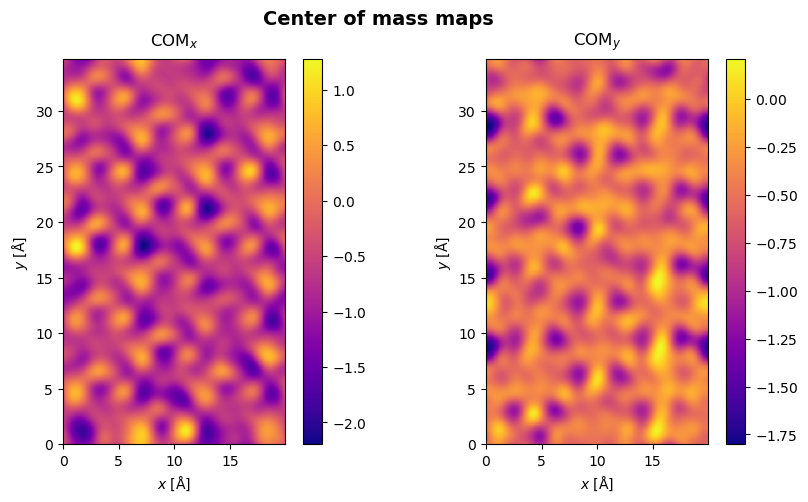

In [284]:
# Interpolating the data to create smoother COM maps
interpolated_COMx = abtem.measurements.Images.from_array_and_metadata(array=com_x, axes_metadata=center_of_mass.axes_metadata)
interpolated_COMy = abtem.measurements.Images.from_array_and_metadata(array=com_y, axes_metadata=center_of_mass.axes_metadata)
interpolated_COMx = interpolated_COMx.interpolate(0.05)
interpolated_COMy = interpolated_COMy.interpolate(0.05)

fig, axs = plt.subplots(1, 2, figsize=(10,5))
interpolated_COMx.show(ax=axs[0], title='COM$_x$', cbar=True, cmap='plasma')
interpolated_COMy.show(ax=axs[1], title='COM$_y$', cbar=True, cmap='plasma')
plt.suptitle('Center of mass maps', fontsize=14, weight='bold')
fig.savefig('COMmaps.svg', dpi=300, bbox_inches='tight')

In [285]:
# Electric field calculations
# Source: https://github.com/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_07/lectures/lecture_7.2_com_dpc_analysis.ipynb

# Calibration for physical units
# (These are typical values - adjust for your experiment)

# Electron parameters (60 keV)
energy_keV = 60.0
wavelength_pm = 4.87  # pm
electron_charge = 1.602e-19  # C
planck_h = 6.626e-34  # J·s
c = 3e8  # m/s

# Sample thickness (estimate)
thickness_nm = 0.4  # nm (adjust based on your sample)

# Calibrations
Q_pixel_size_mrad = 0.1  # mrad/pixel
R_pixel_size_nm = 0.1  # nm/pixel

# Convert COM shift (pixels) to angle (mrad)
com_x_mrad = com_x * Q_pixel_size_mrad
com_y_mrad = com_y * Q_pixel_size_mrad

# Convert to electric field (simplified)
# E ≈ (Δθ * h) / (e * λ * L)
# where Δθ is in radians

conversion_factor = planck_h / (electron_charge * wavelength_pm * 1e-12 * thickness_nm * 1e-9)
# Result will be in V/m

com_x_rad = com_x_mrad * 1e-3  # Convert mrad to rad
com_y_rad = com_y_mrad * 1e-3

E_x = com_x_rad * conversion_factor  # V/m
E_y = com_y_rad * conversion_factor  # V/m
E_magnitude = np.sqrt(E_x**2 + E_y**2)

print("Physical Field Mapping:")
print(f"  Sample thickness (assumed): {thickness_nm} nm")
print(f"  Electron wavelength: {wavelength_pm} pm")
print(f"  Energy: {energy_keV} keV")
print(f"\n  Electric field (estimated):")
print(f"    E_x range: {E_x.min():.2e} to {E_x.max():.2e} V/m")
print(f"    E_y range: {E_y.min():.2e} to {E_y.max():.2e} V/m")
print(f"    |E| mean: {np.mean(E_magnitude):.2e} V/m")
print(f"    |E| max: {np.max(E_magnitude):.2e} V/m")

Physical Field Mapping:
  Sample thickness (assumed): 0.4 nm
  Electron wavelength: 4.87 pm
  Energy: 60.0 keV

  Electric field (estimated):
    E_x range: -4.28e+02 to 2.21e+02 V/m
    E_y range: -3.76e+02 to 3.43e+01 V/m
    |E| mean: 1.88e+02 V/m
    |E| max: 4.41e+02 V/m


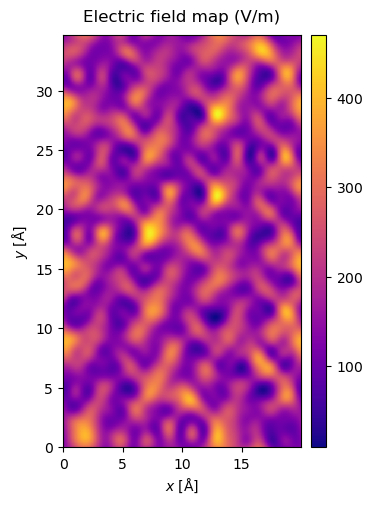

In [220]:
# Visualize electric field
interpolated_E = abtem.measurements.Images.from_array_and_metadata(array=E_magnitude, axes_metadata=center_of_mass.axes_metadata)
interpolated_E = interpolated_E.interpolate(0.05)

Efieldfig = interpolated_E.show(cmap='plasma', cbar=True, title='Electric field map (V/m)')
Efieldfig.get_figure().savefig('Efieldmap.svg', dpi=300, bbox_inches='tight')

In [274]:
# Visualize charge density
# Recall Gauss' law in differential form: div E = p/e_0 where p is the charge density

e_0 = 8.85e-12 # vacuum permittivity

# Assign Ex and Ey maps axes metadata of structure file
interpolated_Ex = abtem.measurements.Images.from_array_and_metadata(array=E_x, axes_metadata=center_of_mass.axes_metadata)
interpolated_Ey = abtem.measurements.Images.from_array_and_metadata(array=E_y, axes_metadata=center_of_mass.axes_metadata)

nx, ny = len(interpolated_Ex.coordinates[0]), len(interpolated_Ex.coordinates[1])
x = interpolated_Ex.coordinates[0]
y = interpolated_Ex.coordinates[1]
dx = (x[1] - x[0]) * 1e-10
dy = (y[1] - y[0]) * 1e-10

dEx_dx = np.gradient(E_x, dx, axis=1)
dEy_dy = np.gradient(E_y, dy, axis=0)
div = dEx_dx + dEy_dy

charge_density = div * e_0 / 1e20 / electron_charge
charge_density = abtem.measurements.Images.from_array_and_metadata(array=charge_density, axes_metadata=center_of_mass.axes_metadata)
charge_density = charge_density.interpolate(0.05)

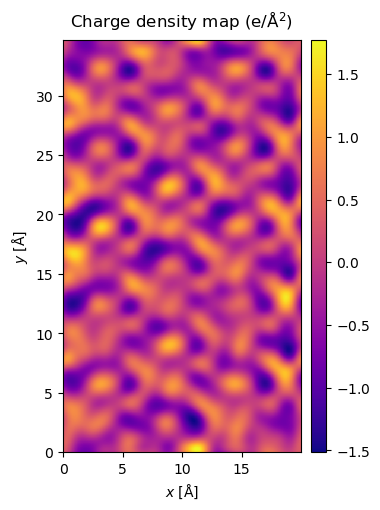

In [286]:
chargefig = charge_density.show(cmap='plasma', cbar=True, title='Charge density map (e/Å$^2$)')
chargefig.get_figure().savefig('chargedensity.svg', dpi=300, bbox_inches='tight')